<a href="https://www.kaggle.com/code/adegbaju/global-food-price-inflation-hunger-index-analysi?scriptVersionId=322099687" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Global Food Price Inflation & Hunger Index Analysis (1990–Present)

- Data loading, cleaning and merging of the FAOSTAT / World Bank panel
- Exploratory Data Analysis (EDA) with professional visualizations
- Feature engineering for time series and food security signals
- Machine learning modelling to predict food crisis flags and price trends
- Model interpretation using SHAP and permutation importance

Author : MARTINS aDEGBAJU

Date   : 2026-05-25

License: CC0 / CC BY 4.0 

DO NOT FORGET TO UPVOTE 


# Setup & Imports

In [1]:
# Standard data science stack with time series and ML extras.

import os, sys, warnings, logging
from pathlib import Path
from typing import Tuple, List, Optional, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Time series
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Machine Learning
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, mean_absolute_error, mean_squared_error,
                             r2_score, roc_auc_score)
from sklearn.inspection import permutation_importance
import xgboost as xgb
import shap

# Configure visuals
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
warnings.filterwarnings('ignore')

# Logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Configuration

In [2]:
# Centralised paths and constants – change these when working locally.

class Config:
    # Kaggle input directory (adjust if using a different dataset path)
    INPUT_DIR = Path("/kaggle/input/datasets/belbino/food-price-inflation-hunger-index-1990-present")
    OUTPUT_DIR = Path("/kaggle/working")
    OUTPUT_DIR.mkdir(exist_ok=True)

    # File names
    COMMODITY_PRICES = "commodity_prices.csv"
    CROP_YIELDS = "crop_yields.csv"
    FOOD_SEC_INDICATORS = "food_security_indicators.csv"
    FOOD_SEC_PANEL = "food_security_panel.csv"
    ML_FEATURES = "ml_features.csv"

    # Date ranges
    MONTHLY_START = "1990-01-31"
    MONTHLY_END = "2024-12-31"  # based on data preview

    # Model settings
    TEST_SIZE = 0.2  # 20% most recent for time series holdout
    RANDOM_STATE = 42
    CV_SPLITS = 5

# Data Loading Functions

In [3]:
# Robust loaders with error handling and basic validation.

def load_commodity_prices(config: Config) -> pd.DataFrame:
    """Load monthly commodity and fertiliser prices."""
    path = config.INPUT_DIR / config.COMMODITY_PRICES
    logger.info(f"Loading {path}")
    df = pd.read_csv(path, parse_dates=['date'])
    df = df.rename(columns=str.lower).drop_duplicates()
    # Ensure date is datetime and sorted
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)
    logger.info(f"  -> shape {df.shape}, range {df.date.min().date()} - {df.date.max().date()}")
    return df

def load_crop_yields(config: Config) -> pd.DataFrame:
    """Load annual crop yield and production data."""
    path = config.INPUT_DIR / config.CROP_YIELDS
    logger.info(f"Loading {path}")
    df = pd.read_csv(path)
    # Assuming a 'year' column or date; column names likely start with crop names
    # Check if there is a 'date' column; if not, look for 'year'
    if 'year' in df.columns:
        df['year'] = df['year'].astype(int)
        df = df.sort_values('year').reset_index(drop=True)
    elif 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df['year'] = df['date'].dt.year
    else:
        raise KeyError("Crop yields file must contain 'year' or 'date' column")
    logger.info(f"  -> shape {df.shape}")
    return df

def load_food_security_indicators(config: Config) -> pd.DataFrame:
    """Load annual food security indicators (undernourishment, cereal yield, etc.)."""
    path = config.INPUT_DIR / config.FOOD_SEC_INDICATORS
    logger.info(f"Loading {path}")
    df = pd.read_csv(path)
    # This file has 'year' column; some years are float due to missing (e.g., 1961.0)
    df['year'] = df['year'].round().astype(int)
    df = df.sort_values('year').reset_index(drop=True)
    logger.info(f"  -> shape {df.shape}")
    return df

def load_food_security_panel(config: Config) -> pd.DataFrame:
    """Load the main monthly panel with all derived ratios and price indices."""
    path = config.INPUT_DIR / config.FOOD_SEC_PANEL
    logger.info(f"Loading {path}")
    df = pd.read_csv(path, parse_dates=['date'])
    df = df.rename(columns=str.lower).drop_duplicates()
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)
    logger.info(f"  -> shape {df.shape}")
    return df

def load_ml_features(config: Config) -> pd.DataFrame:
    """Load pre-built ML feature set with target variables."""
    path = config.INPUT_DIR / config.ML_FEATURES
    logger.info(f"Loading {path}")
    df = pd.read_csv(path, parse_dates=['date'])
    df = df.rename(columns=str.lower).drop_duplicates()
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)
    logger.info(f"  -> shape {df.shape}, columns: {df.columns.tolist()}")
    return df

# Data Cleaning & Merging

In [4]:
def clean_panel_data(df: pd.DataFrame) -> pd.DataFrame:
    """Standardise column names, handle missing values, add time components."""
    # Convert all column names to lowercase
    df.columns = [c.strip().lower() for c in df.columns]
    
    # Fill missing values with forward fill then backward fill (common for prices)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(method='ffill').fillna(method='bfill')
    
    # Add time features
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter
    
    # Sort
    df = df.sort_values('date').reset_index(drop=True)
    return df

# Exploratory Data Analysis (EDA)

In [5]:
# Comprehensive visual exploration of prices, hunger index, and derived stress signals.

def plot_price_trends(panel: pd.DataFrame):
    """Plot key commodity prices and FAO Food Price Index over time."""
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # Panel A: FAO Food Price Index (overall + cereals)
    ax = axes[0, 0]
    if 'ffpi_overall' in panel.columns and 'ffpi_cereals' in panel.columns:
        ax.plot(panel['date'], panel['ffpi_overall'], label='FFPI Overall', lw=2)
        ax.plot(panel['date'], panel['ffpi_cereals'], label='FFPI Cereals', lw=2)
        ax.axhline(130, color='red', linestyle='--', label='Crisis threshold (130)')
        ax.set_title('FAO Food Price Index (2014-2016=100)')
        ax.legend()
    else:
        ax.text(0.5, 0.5, 'FFPI columns missing', ha='center', va='center')
    
    # Panel B: Grain prices (wheat, maize, rice)
    ax = axes[0, 1]
    grains = ['wheat_usd_mt', 'maize_usd_mt', 'rice_usd_mt']
    available = [g for g in grains if g in panel.columns]
    if available:
        for col in available:
            ax.plot(panel['date'], panel[col], label=col.replace('_usd_mt','').capitalize(), lw=1.5)
        ax.set_title('Grain Prices (USD/MT)')
        ax.legend()
    else:
        ax.text(0.5, 0.5, 'No grain price columns', ha='center', va='center')
    
    # Panel C: Fertiliser prices
    ax = axes[1, 0]
    ferts = ['dap_fertiliser_usd_mt', 'urea_usd_mt', 'mop_potash_usd_mt']
    available_fert = [f for f in ferts if f in panel.columns]
    if available_fert:
        for col in available_fert:
            ax.plot(panel['date'], panel[col], label=col.replace('_usd_mt','').replace('_',' ').title(), lw=1.5)
        ax.set_title('Fertiliser Prices (USD/MT)')
        ax.legend()
    
    # Panel D: Food shock score / crisis flags
    ax = axes[1, 1]
    shock_cols = ['food_shock_score', 'ffpi_crisis_flag', 'supply_stress_flag']
    present = [c for c in shock_cols if c in panel.columns]
    if present:
        for col in present:
            # scale for visibility
            ax.plot(panel['date'], panel[col], label=col, lw=1.5, alpha=0.7)
        ax.set_title('Food Crisis Stress Indicators')
        ax.legend()
    
    plt.tight_layout()
    plt.savefig(Config.OUTPUT_DIR / 'price_trends.png')
    plt.show()

def plot_volatility_and_affordability(panel: pd.DataFrame):
    """Examine 12-month FFPI volatility and cereals affordability index."""
    fig, ax1 = plt.subplots(figsize=(14, 6))
    if 'ffpi_volatility_12m' in panel.columns:
        ax1.plot(panel['date'], panel['ffpi_volatility_12m'], color='darkred', lw=1.5, label='FFPI Volatility (12m)')
        ax1.axhline(3, color='grey', linestyle='--', label='Elevated (>3)')
        ax1.set_ylabel('Volatility (std of MoM changes)')
    ax1.set_title('Price Volatility & Cereals Affordability')
    ax2 = ax1.twinx()
    if 'cereals_affordability_idx' in panel.columns:
        ax2.plot(panel['date'], panel['cereals_affordability_idx'], color='teal', lw=2, label='Cereals Affordability')
        ax2.axhline(100, color='black', linestyle=':', label='Baseline 2014-2016')
        ax2.set_ylabel('Affordability Index (100 = baseline)')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
    plt.savefig(Config.OUTPUT_DIR / 'volatility_affordability.png')
    plt.show()

def plot_security_indicators(indicators: pd.DataFrame):
    """Plot annual undernourishment and cereal yield trends."""
    df = indicators.dropna(subset=['undernourishment_pct']).copy()
    fig, ax1 = plt.subplots(figsize=(14, 6))
    ax1.plot(df['year'], df['undernourishment_pct'], marker='o', color='darkorange', lw=2, label='Undernourishment %')
    ax1.set_ylabel('Undernourishment (%)')
    ax2 = ax1.twinx()
    ax2.plot(df['year'], df['cereal_yield_kg_ha'], marker='s', color='steelblue', lw=2, label='Cereal Yield (kg/ha)')
    ax2.set_ylabel('Cereal Yield (kg/ha)')
    ax1.set_title('Global Undernourishment vs Cereal Yield (FAOSTAT)')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1+lines2, labels1+labels2)
    plt.savefig(Config.OUTPUT_DIR / 'undernourishment_yield.png')
    plt.show()

def correlation_heatmap(panel: pd.DataFrame):
    """Generate a correlation heatmap for key numeric features."""
    # Select a manageable set of columns
    key_cols = [c for c in panel.columns if c not in ['date','year','month','quarter'] 
                and panel[c].dtype in ['float64','int64']]
    # Limit to top 20 most correlated with FFPI if present
    if 'ffpi_overall' in panel.columns:
        corr = panel[key_cols].corr()
        top_cols = corr['ffpi_overall'].abs().sort_values(ascending=False).head(20).index.tolist()
    else:
        top_cols = key_cols[:20]
    
    plt.figure(figsize=(16, 12))
    sns.heatmap(panel[top_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0,
                square=True, linewidths=0.5)
    plt.title('Correlation Heatmap of Key Food Security Features')
    plt.tight_layout()
    plt.savefig(Config.OUTPUT_DIR / 'correlation_heatmap.png')
    plt.show()


# Feature Engineering

In [6]:
# Create additional time-based features and lagged variables for ML.

def engineer_features(df: pd.DataFrame, target_cols: List[str] = None) -> pd.DataFrame:
    """
    Add lagged features, rolling statistics, and ratios.
    If df is already the ml_features dataset, we just ensure proper sorting.
    """
    df = df.copy()
    # Time components
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter
    df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
    df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)
    
    # Price lags (for common commodities)
    price_cols = ['wheat_usd_mt', 'maize_usd_mt', 'soybean_oil_usd_mt', 
                  'dap_fertiliser_usd_mt', 'mop_potash_usd_mt']
    for col in price_cols:
        if col in df.columns:
            df[f'{col}_lag1'] = df[col].shift(1)
            df[f'{col}_lag3'] = df[col].shift(3)
            df[f'{col}_lag6'] = df[col].shift(6)
            df[f'{col}_rolling_mean_3m'] = df[col].rolling(3).mean()
            df[f'{col}_rolling_std_3m'] = df[col].rolling(3).std()
    
    # FAO index lags
    for idx in ['ffpi_overall', 'ffpi_cereals', 'ffpi_meat', 'ffpi_dairy', 'ffpi_oils', 'ffpi_sugar']:
        if idx in df.columns:
            df[f'{idx}_lag1'] = df[idx].shift(1)
            df[f'{idx}_mom_change'] = df[idx].pct_change()
    
    # Supply stress interaction
    if 'supply_stress_flag' in df.columns and 'ffpi_crisis_flag' in df.columns:
        df['double_stress'] = ((df['supply_stress_flag'] == 1) & (df['ffpi_crisis_flag'] == 1)).astype(int)
    
    # Drop rows with NaN created by lags
    df = df.dropna().reset_index(drop=True)
    return df


# Model Training & Evaluation (ML)

In [7]:
# Using the pre-built ml_features.csv which contains targets.

def prepare_ml_data(config: Config) -> Tuple[pd.DataFrame, List[str], List[str]]:
    """Load and split the ml_features dataset into features (X) and targets (y)."""
    ml = load_ml_features(config)
    # The dataset contains target columns: target_ffpi_chg_1m, target_ffpi_chg_12m, 
    # target_ffpi_up_12m, target_cereals_chg_1m, target_shock_next_month
    target_cols = [c for c in ml.columns if c.startswith('target_')]
    logger.info(f"Target columns found: {target_cols}")
    
    # Separate features and targets
    feature_cols = [c for c in ml.columns if c not in target_cols + ['date']]
    X = ml[feature_cols].copy()
    y = ml[target_cols].copy()
    
    # Ensure all features are numeric (drop any non-numeric that slipped through)
    X = X.select_dtypes(include=[np.number])
    
    # Handle any remaining NaNs (should be minimal)
    X = X.fillna(method='ffill').fillna(method='bfill')
    y = y.fillna(method='ffill').fillna(method='bfill')
    
    # Time-based split: last 20% as test
    split_idx = int(len(ml) * (1 - config.TEST_SIZE))
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    train_dates = ml['date'].iloc[:split_idx]
    test_dates = ml['date'].iloc[split_idx:]
    
    logger.info(f"Train: {X_train.shape}, Test: {X_test.shape}")
    return (X_train, X_test, y_train, y_test), feature_cols, target_cols, train_dates, test_dates

def train_classification_model(X_train, y_train, target_name: str):
    """Train an XGBoost classifier for a binary target (e.g., target_shock_next_month)."""
    logger.info(f"Training classifier for {target_name}")
    model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=Config.RANDOM_STATE,
        eval_metric='logloss',
        use_label_encoder=False
    )
    # Scale features
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X_train)
    model.fit(X_scaled, y_train[target_name])
    return model, scaler

def train_regression_model(X_train, y_train, target_name: str):
    """Train an XGBoost regressor for a continuous target."""
    logger.info(f"Training regressor for {target_name}")
    model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=Config.RANDOM_STATE
    )
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X_train)
    model.fit(X_scaled, y_train[target_name])
    return model, scaler

def evaluate_model(model, scaler, X_test, y_test, target_name: str, is_classification=True):
    """Evaluate model and return metrics and predictions."""
    X_scaled = scaler.transform(X_test)
    if is_classification:
        y_pred_prob = model.predict_proba(X_scaled)[:, 1]
        y_pred = model.predict(X_scaled)
        acc = accuracy_score(y_test[target_name], y_pred)
        prec = precision_score(y_test[target_name], y_pred)
        rec = recall_score(y_test[target_name], y_pred)
        f1 = f1_score(y_test[target_name], y_pred)
        auc = roc_auc_score(y_test[target_name], y_pred_prob)
        logger.info(f"  {target_name} - Acc:{acc:.3f} Prec:{prec:.3f} Rec:{rec:.3f} F1:{f1:.3f} AUC:{auc:.3f}")
        return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'auc': auc}, y_pred
    else:
        y_pred = model.predict(X_scaled)
        mae = mean_absolute_error(y_test[target_name], y_pred)
        rmse = np.sqrt(mean_squared_error(y_test[target_name], y_pred))
        r2 = r2_score(y_test[target_name], y_pred)
        logger.info(f"  {target_name} - MAE:{mae:.4f} RMSE:{rmse:.4f} R²:{r2:.4f}")
        return {'mae': mae, 'rmse': rmse, 'r2': r2}, y_pred

def plot_feature_importance(model, feature_names, target_name, top_n=20):
    """Plot SHAP summary and feature importance."""
    # For simplicity, use built-in importance if SHAP not feasible on large test set
    plt.figure(figsize=(12, 8))
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1][:top_n]
        plt.barh(range(top_n), importances[indices][::-1], align='center')
        plt.yticks(range(top_n), [feature_names[i] for i in indices][::-1])
        plt.xlabel('Feature Importance (Gain)')
        plt.title(f'Top {top_n} Features for {target_name}')
        plt.tight_layout()
        plt.savefig(Config.OUTPUT_DIR / f'importance_{target_name}.png')
        plt.show()

def time_series_cv_and_report(X_train, y_train, X_test, y_test, feature_names, target_name, is_classification):
    """Run a full modeling pipeline and produce evaluation report."""
    if is_classification:
        model, scaler = train_classification_model(X_train, y_train, target_name)
    else:
        model, scaler = train_regression_model(X_train, y_train, target_name)
    metrics, y_pred = evaluate_model(model, scaler, X_test, y_test, target_name, is_classification)
    plot_feature_importance(model, feature_names, target_name)
    return model, scaler, metrics, y_pred


#  Main Analysis Pipeline

2026-05-25 17:23:24,079 - INFO - ====== Starting Global Food Security Analysis ======
2026-05-25 17:23:24,080 - INFO - Loading datasets...
2026-05-25 17:23:24,081 - INFO - Loading /kaggle/input/datasets/belbino/food-price-inflation-hunger-index-1990-present/food_security_panel.csv
2026-05-25 17:23:24,129 - INFO -   -> shape (420, 38)
2026-05-25 17:23:24,130 - INFO - Loading /kaggle/input/datasets/belbino/food-price-inflation-hunger-index-1990-present/food_security_indicators.csv
2026-05-25 17:23:24,138 - INFO -   -> shape (63, 8)
2026-05-25 17:23:24,155 - INFO - Performing EDA...


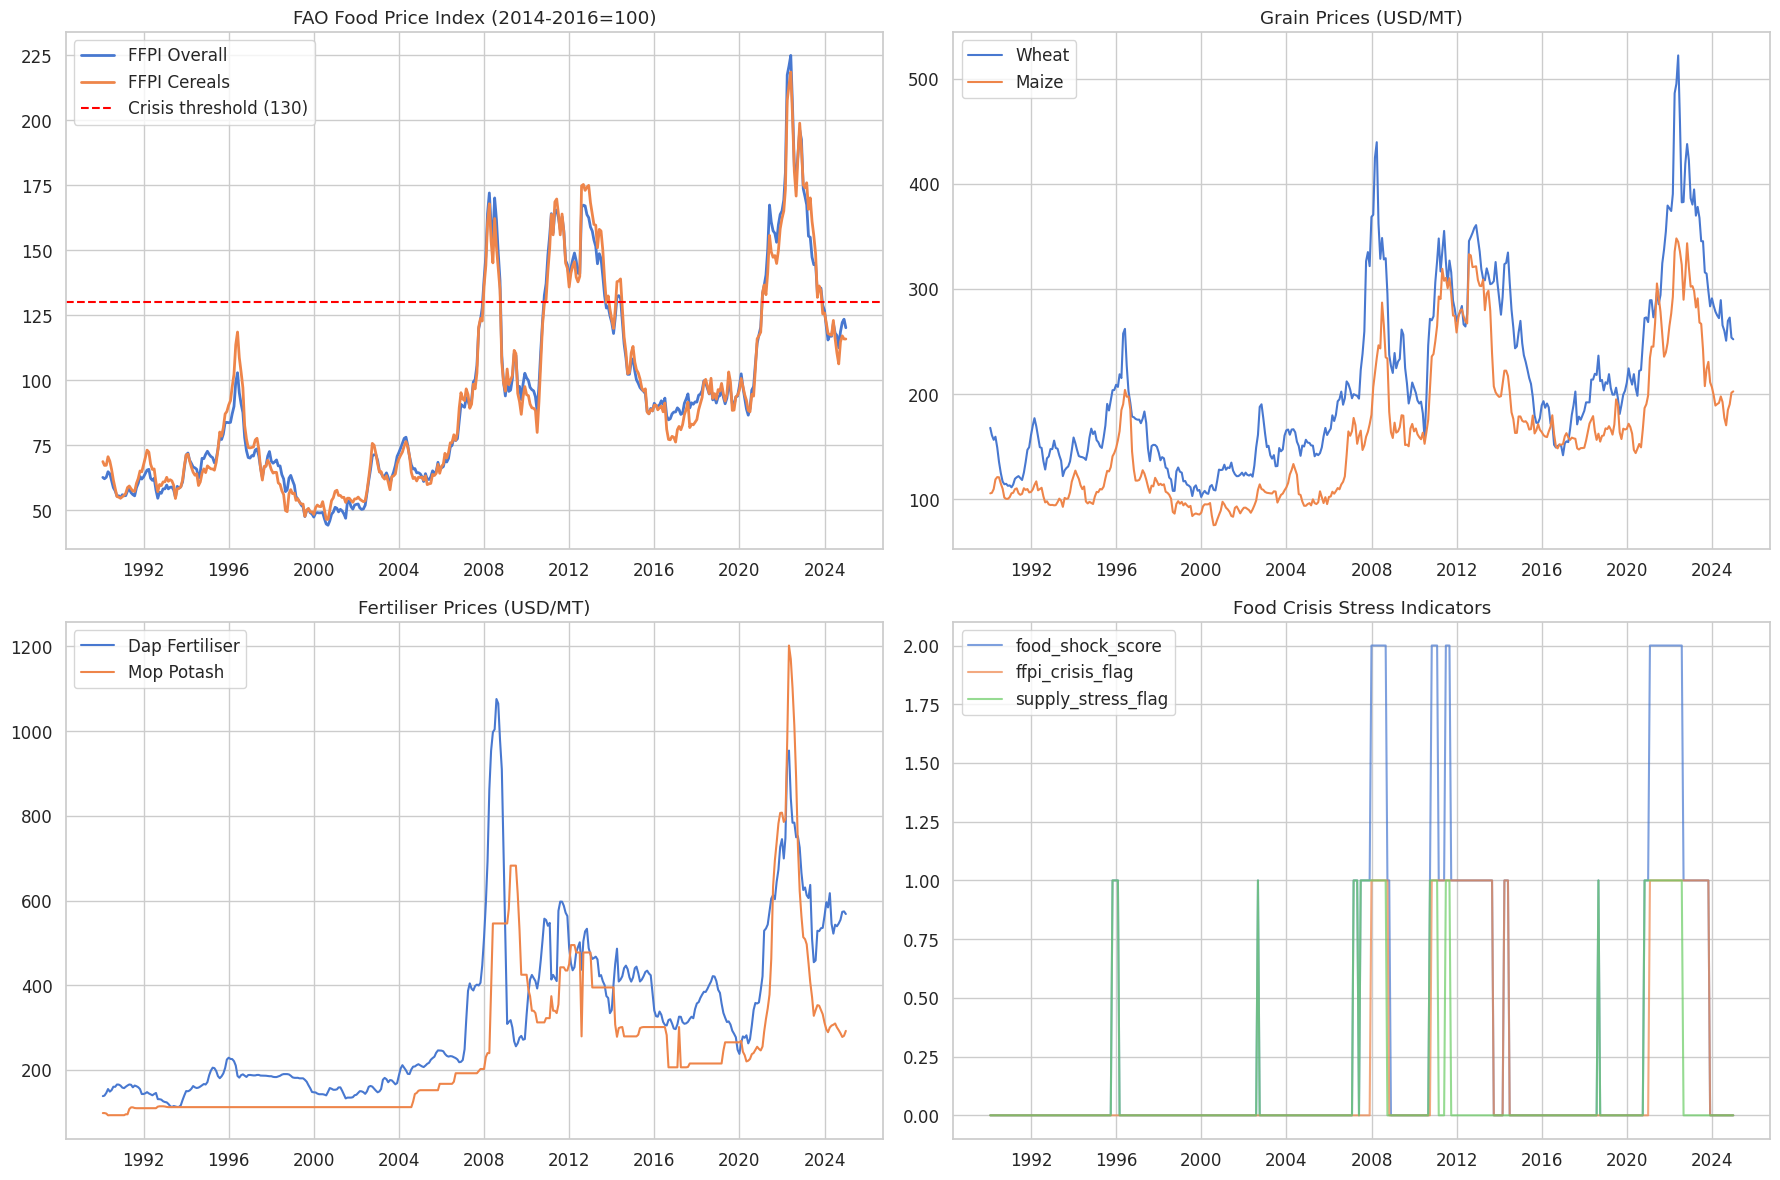

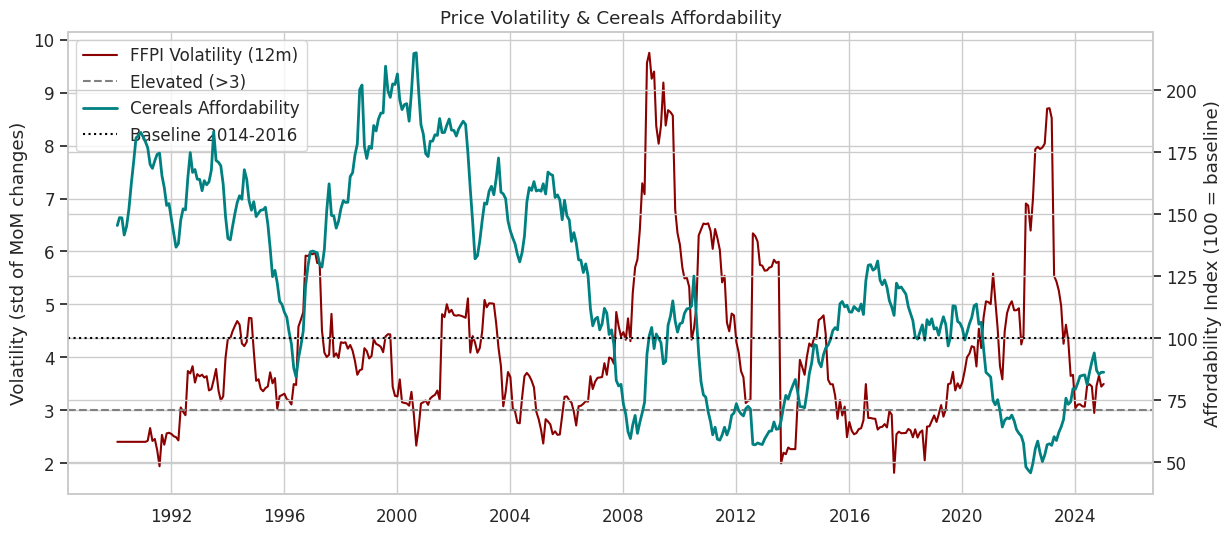

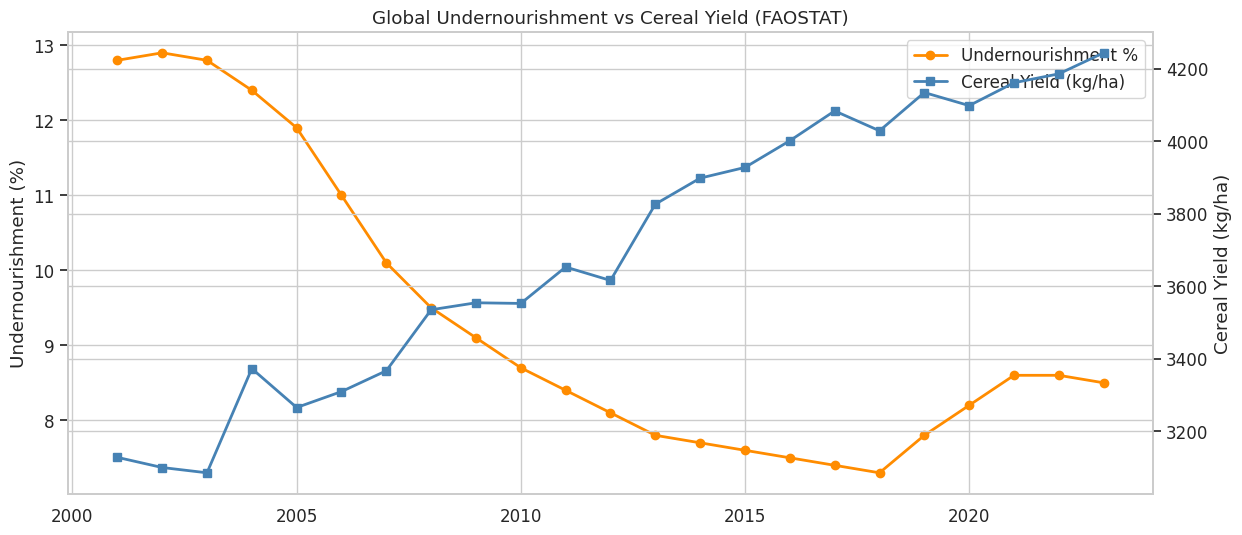

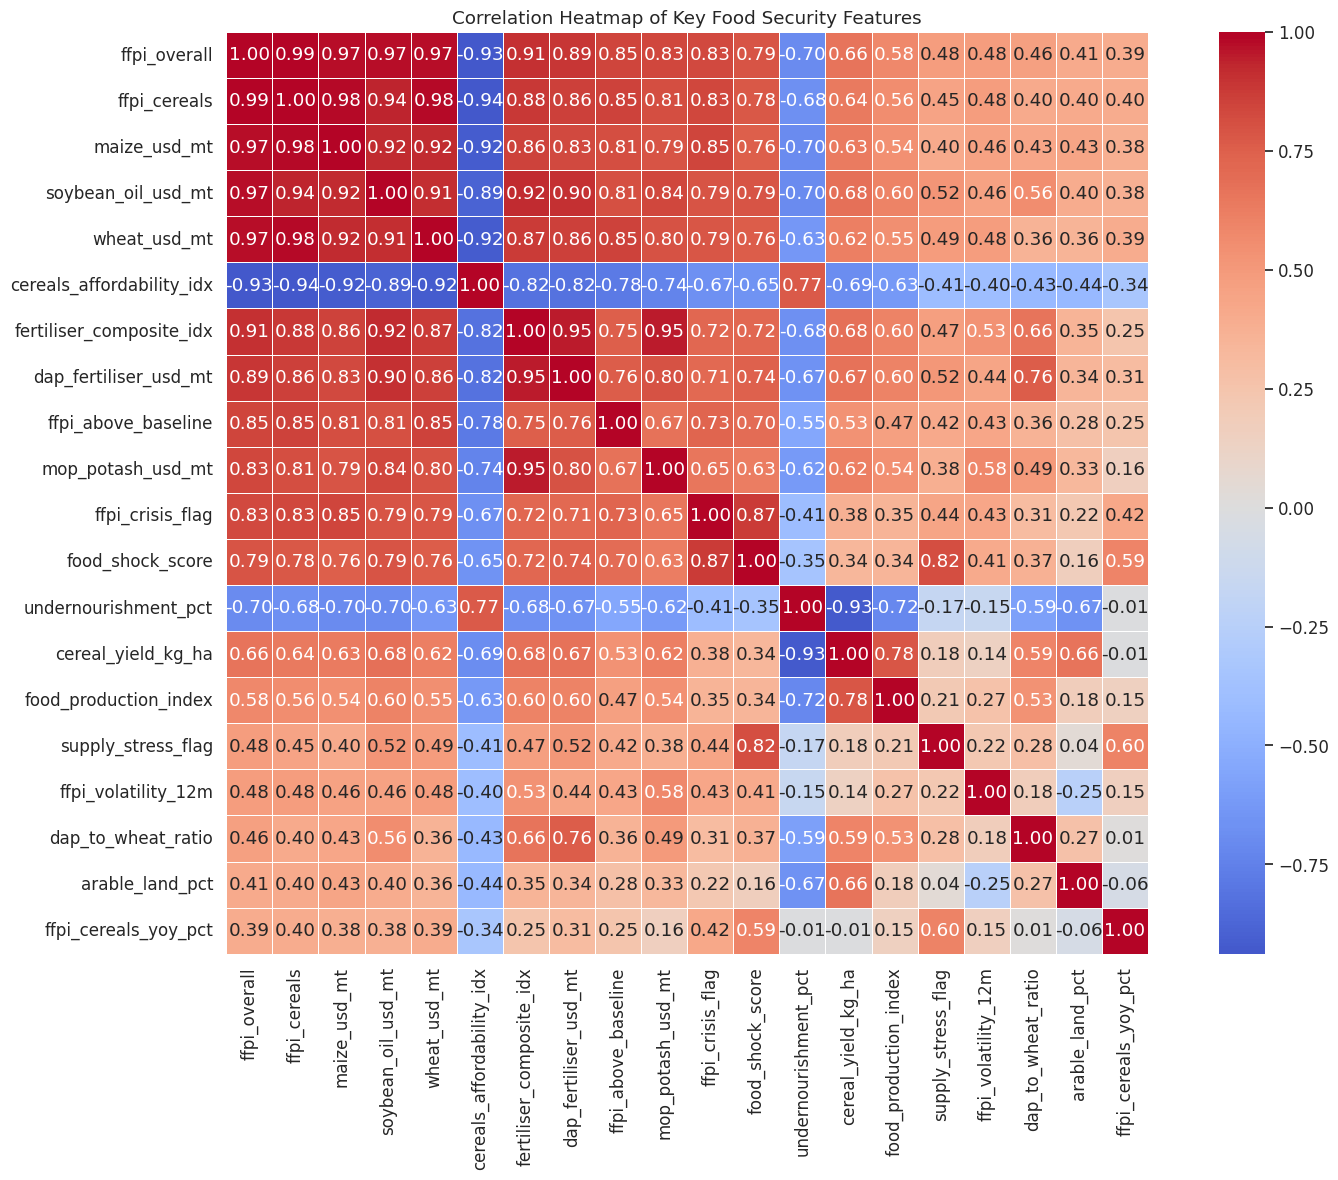

2026-05-25 17:23:29,292 - INFO - Engineering features from panel...
2026-05-25 17:23:29,353 - INFO - Building ML models using ml_features.csv...
2026-05-25 17:23:29,354 - INFO - Loading /kaggle/input/datasets/belbino/food-price-inflation-hunger-index-1990-present/ml_features.csv
2026-05-25 17:23:29,407 - INFO -   -> shape (419, 189), columns: ['date', 'soybean_oil_usd_mt', 'maize_usd_mt', 'wheat_usd_mt', 'dap_fertiliser_usd_mt', 'mop_potash_usd_mt', 'wheat_usd_mt_mom_pct', 'wheat_usd_mt_yoy_pct', 'maize_usd_mt_mom_pct', 'maize_usd_mt_yoy_pct', 'soybean_oil_usd_mt_mom_pct', 'soybean_oil_usd_mt_yoy_pct', 'dap_fertiliser_usd_mt_mom_pct', 'dap_fertiliser_usd_mt_yoy_pct', 'mop_potash_usd_mt_mom_pct', 'mop_potash_usd_mt_yoy_pct', 'dap_to_wheat_ratio', 'fertiliser_composite_idx', 'undernourishment_pct', 'food_production_index', 'cereal_yield_kg_ha', 'arable_land_pct', 'undernourishment_pct_yoy_chg', 'food_production_index_yoy_chg', 'cereal_yield_kg_ha_yoy_chg', 'ffpi_overall', 'ffpi_cereals',

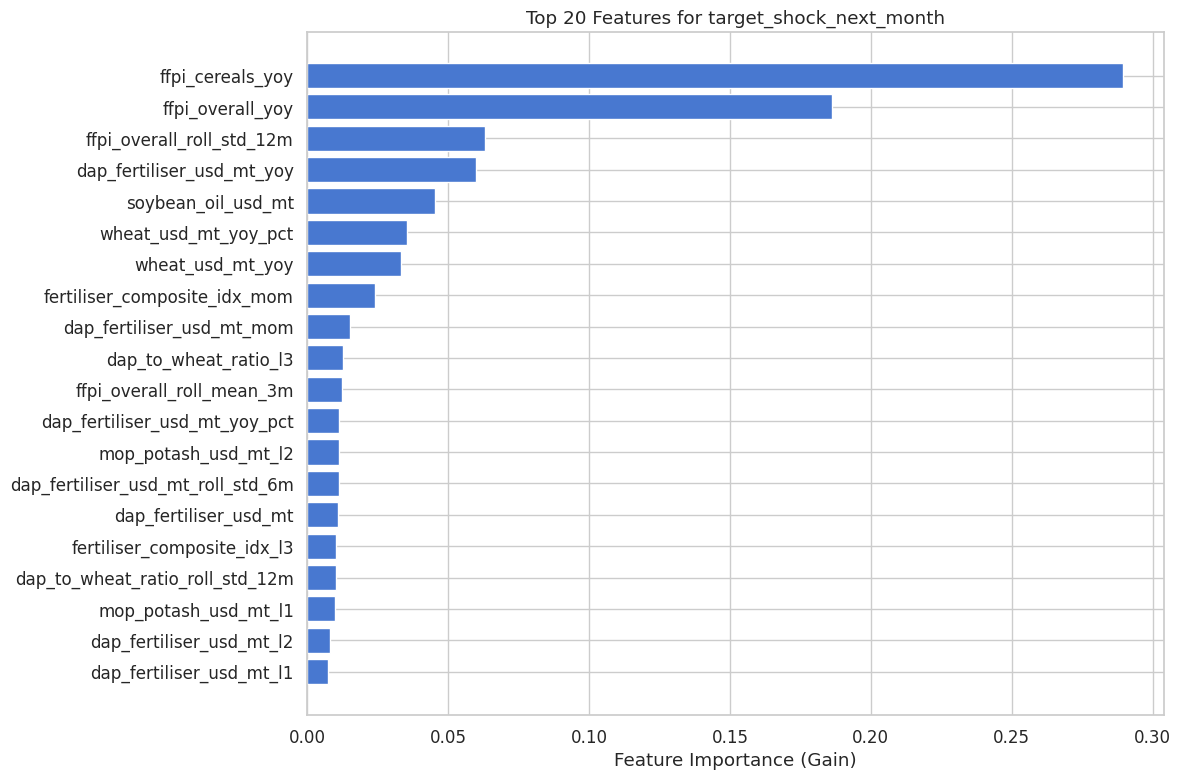

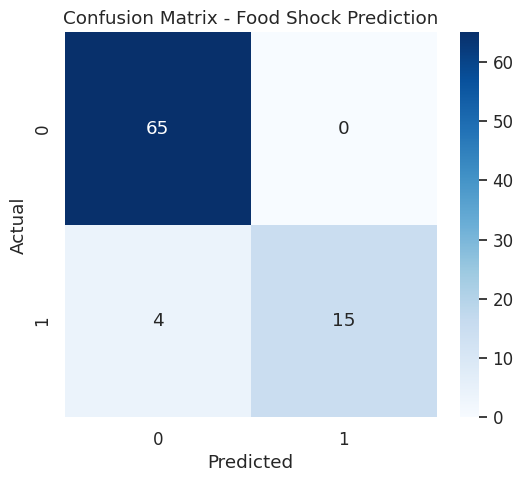

2026-05-25 17:23:30,586 - INFO - Training model for 12-month FFPI change prediction...
2026-05-25 17:23:30,588 - INFO - Training regressor for target_ffpi_chg_12m
2026-05-25 17:23:34,912 - INFO -   target_ffpi_chg_12m - MAE:19.9297 RMSE:29.6702 R²:-0.1772


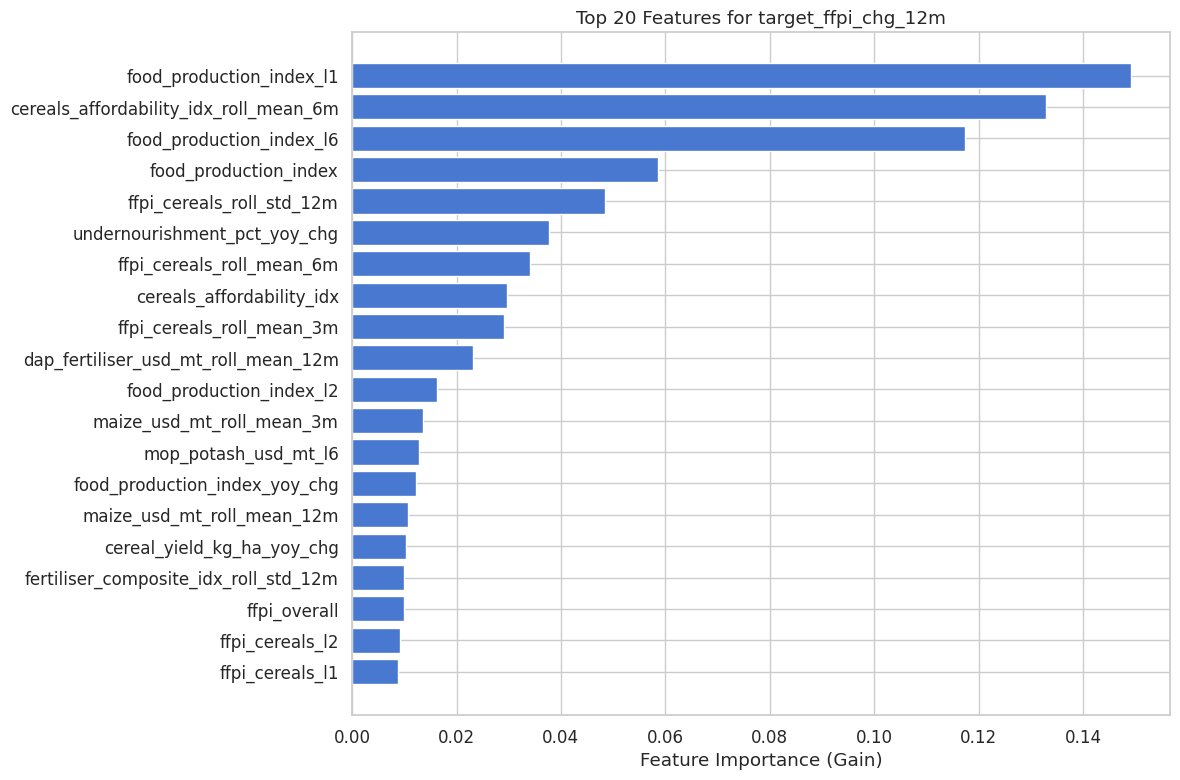

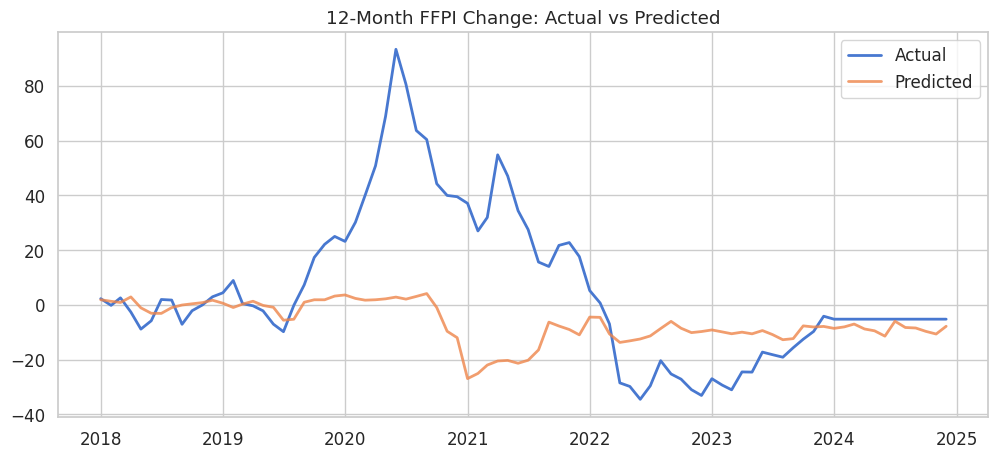

2026-05-25 17:23:35,986 - INFO - ====== Analysis Complete ======
2026-05-25 17:23:35,987 - INFO - Outputs saved to /kaggle/working


In [8]:
# Assemble all steps.

def main():
    config = Config()
    logger.info("====== Starting Global Food Security Analysis ======")
    
    # 1. Load data
    logger.info("Loading datasets...")
    panel = load_food_security_panel(config)
    indicators = load_food_security_indicators(config)
    # Optional: load other CSVs if needed
    # commodities = load_commodity_prices(config)
    # yields = load_crop_yields(config)
    
    # 2. Clean panel
    panel = clean_panel_data(panel)
    
    # 3. EDA
    logger.info("Performing EDA...")
    plot_price_trends(panel)
    plot_volatility_and_affordability(panel)
    plot_security_indicators(indicators)
    correlation_heatmap(panel)
    
    # 4. Feature Engineering (if using raw panel, but we'll focus on ML features)
    logger.info("Engineering features from panel...")
    panel_fe = engineer_features(panel)
    # (Optional) Save engineered dataset
    panel_fe.to_csv(config.OUTPUT_DIR / 'panel_engineered.csv', index=False)
    
    # 5. ML Modeling using pre-built ML features
    logger.info("Building ML models using ml_features.csv...")
    (X_train, X_test, y_train, y_test), feature_names, target_cols, train_dates, test_dates = prepare_ml_data(config)
    
    # Choose a binary target – e.g., target_shock_next_month
    if 'target_shock_next_month' in target_cols:
        logger.info("Training model for food shock prediction...")
        model_clf, scaler_clf, metrics_clf, y_pred_clf = time_series_cv_and_report(
            X_train, y_train, X_test, y_test, feature_names,
            target_name='target_shock_next_month',
            is_classification=True
        )
        # Confusion matrix
        cm = confusion_matrix(y_test['target_shock_next_month'], y_pred_clf)
        plt.figure(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title('Confusion Matrix - Food Shock Prediction')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.savefig(config.OUTPUT_DIR / 'confusion_shock.png')
        plt.show()
    
    # Regression target: target_ffpi_chg_12m
    if 'target_ffpi_chg_12m' in target_cols:
        logger.info("Training model for 12-month FFPI change prediction...")
        model_reg, scaler_reg, metrics_reg, y_pred_reg = time_series_cv_and_report(
            X_train, y_train, X_test, y_test, feature_names,
            target_name='target_ffpi_chg_12m',
            is_classification=False
        )
        # Actual vs Predicted plot
        plt.figure(figsize=(12, 5))
        plt.plot(test_dates, y_test['target_ffpi_chg_12m'], label='Actual', lw=2)
        plt.plot(test_dates, y_pred_reg, label='Predicted', lw=2, alpha=0.8)
        plt.title('12-Month FFPI Change: Actual vs Predicted')
        plt.legend()
        plt.savefig(config.OUTPUT_DIR / 'ffpi_chg_12m_predictions.png')
        plt.show()
    
    logger.info("====== Analysis Complete ======")
    logger.info(f"Outputs saved to {config.OUTPUT_DIR}")

if __name__ == "__main__":
    main()

